In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
df = pd.read_csv(os.path.join("~/gcs-data", "GBD_paper", "sbod_data_cleaned.csv"))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161028 entries, 0 to 161027
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Year           161028 non-null  int64
 1   Cause          161028 non-null  str  
 2   Location       161028 non-null  str  
 3   Age            161028 non-null  str  
 4   Sex            161028 non-null  str  
 5   RAG            161028 non-null  str  
 6   Measure        161028 non-null  str  
 7   Value          161028 non-null  str  
 8   Small numbers  161028 non-null  str  
dtypes: int64(1), str(8)
memory usage: 11.1 MB


In [3]:
df["Location"].unique()

<StringArray>
[                     'Scotland',                 'East Scotland',
                 'West Scotland',                'North Scotland',
        'NHS Ayrshire and Arran',                   'NHS Borders',
     'NHS Dumfries and Galloway',              'NHS Forth Valley',
                  'NHS Grampian',                  'NHS Highland',
                   'NHS Lothian',                    'NHS Orkney',
                  'NHS Shetland',             'NHS Western Isles',
                      'NHS Fife',                   'NHS Tayside',
 'NHS Greater Glasgow and Clyde',               'NHS Lanarkshire']
Length: 18, dtype: str

In [4]:
folder = "data"
f_corr, m_corr = {}, {}

for loc in df["Location"].unique():
    file = f"{loc.replace(' ', '_').lower()}_analysis.xlsx"
    if not os.path.exists(os.path.join(folder, file)):
        continue
    cols = [f"{loc}_CAGR_2014", f"{loc}_CAGR_2017"] + [f"{loc}_tsq2_{norm_mode}" for norm_mode in ["mean", "median", "interval", "base"]] + [f"{loc}_tsq3_{norm_mode}" for norm_mode in ["mean", "median", "interval", "base"]]
    if file.endswith(".xlsx"):
        f_df = pd.read_excel(os.path.join(folder, file), sheet_name="Female")
        m_df = pd.read_excel(os.path.join(folder, file), sheet_name="Male")
        f_corr[loc] = {
                        "Pearson": f_df[cols].corr(method="pearson").loc[cols[0]][[col for col in cols if "tsq2" in col]].tolist(),
                        "Spearman": f_df[cols].corr(method="spearman").loc[cols[0]][[col for col in cols if "tsq2" in col]].tolist(),
                        "Kendall": f_df[cols].corr(method="kendall").loc[cols[0]][[col for col in cols if "tsq2" in col]].tolist()
                    }
        m_corr[loc] = {
                        "Pearson": m_df[cols].corr(method="pearson").loc[cols[0]][[col for col in cols if "tsq2" in col]].tolist(),
                        "Spearman": m_df[cols].corr(method="spearman").loc[cols[0]][[col for col in cols if "tsq2" in col]].tolist(),
                        "Kendall": m_df[cols].corr(method="kendall").loc[cols[0]][[col for col in cols if "tsq2" in col]].tolist()
                    }
len(f_corr), len(m_corr)

(17, 17)

In [24]:
def plot_boxes(data, corr_type, gender="Females"):
    all_corr = []

    for d in data:
        all_corr.extend(d["corr"])

    min_val = min([min(d["corr"]) for d in data])
    max_val = max([max(d["corr"]) for d in data])
    mean_val = sum([sum(d["corr"]) for d in data]) / sum([len(d["corr"]) for d in data])
    median_val = np.median(all_corr)

    plot_data = pd.DataFrame(
        [{"loc": d["loc"], "corr": v} for d in data for v in d["corr"]]
    )

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=plot_data, x="loc", y="corr")
    plt.axhline(min_val, color="red", linestyle="--")
    plt.axhline(max_val, color="red", linestyle="--")
    plt.axhline(mean_val, color="blue", linestyle="--")
    plt.axhline(median_val, color="green", linestyle="--")
    # Annotate the min and max values
    plt.text(0, min_val, f"Min: {min_val:.2f}", color="red", va="bottom", ha="left")
    plt.text(0, max_val, f"Max: {max_val:.2f}", color="red", va="bottom", ha="left")
    plt.text(0, mean_val, f"Mean: {mean_val:.2f}", color="blue", va="bottom", ha="left")
    plt.text(0, median_val, f"Median: {median_val:.2f}", color="green", va="bottom", ha="left")

    plt.xticks(rotation=90)
    plt.title(f"{corr_type} Correlation between CAGR and tsq2 for {gender}")
    plt.ylabel("Correlation Coefficient")
    plt.xlabel("Location")
    plt.tight_layout()
    plt.show()

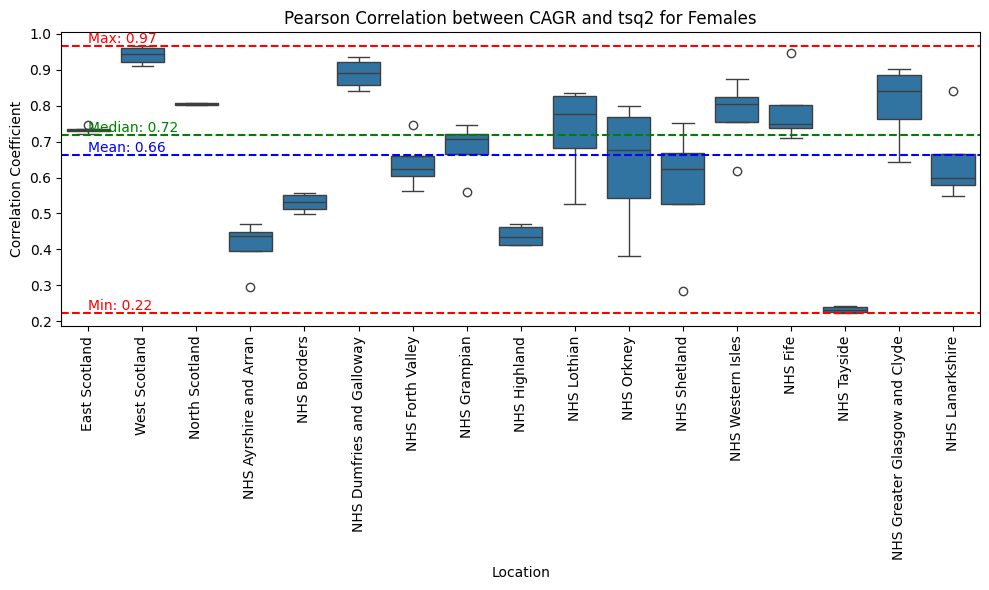

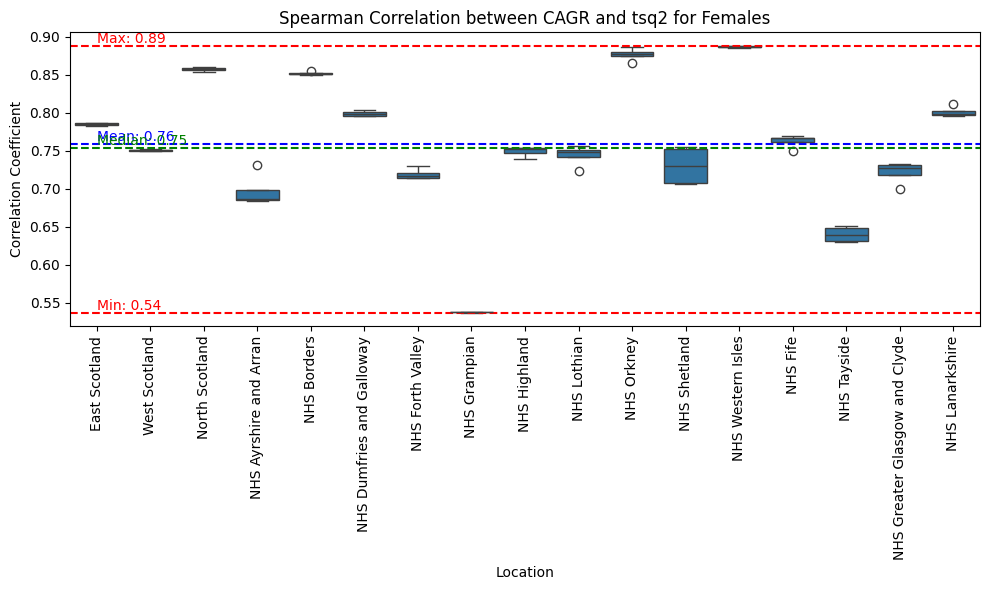

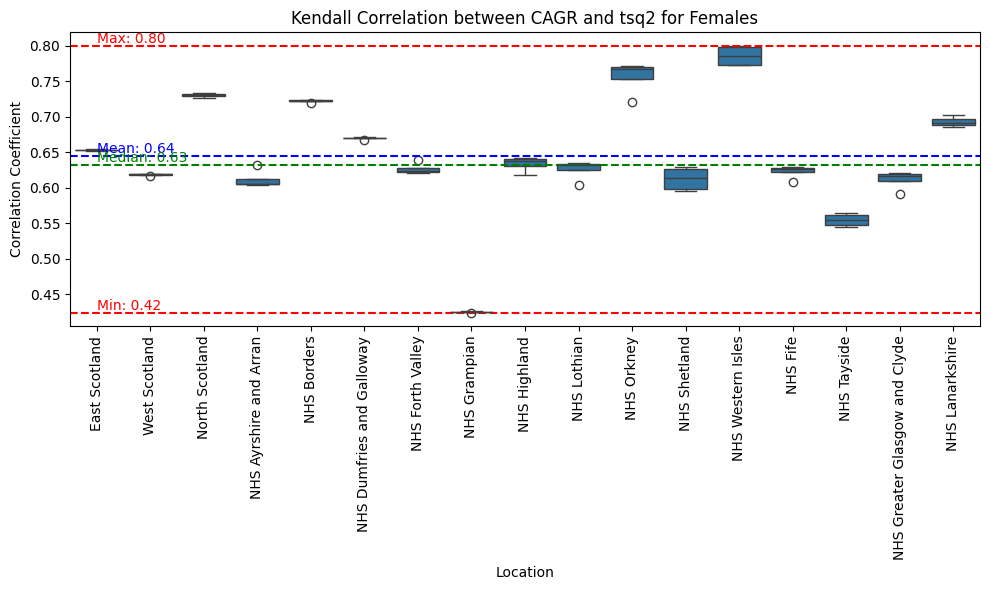

In [27]:
for corr_type in ["Pearson", "Spearman", "Kendall"]:
    data = [{"loc": loc, "corr": f_corr[loc][corr_type]} for loc in f_corr]
    plot_boxes(data, corr_type)

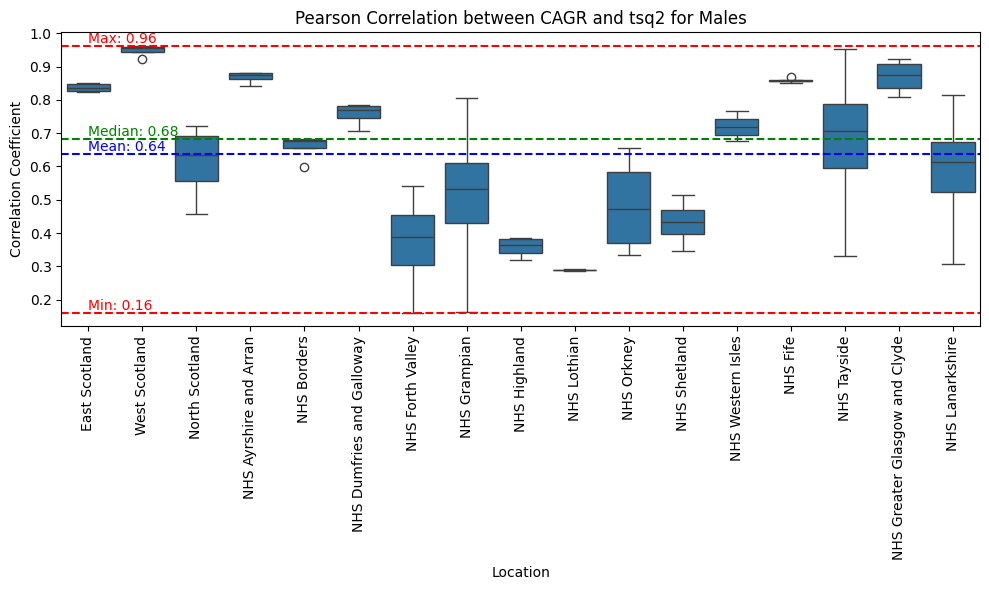

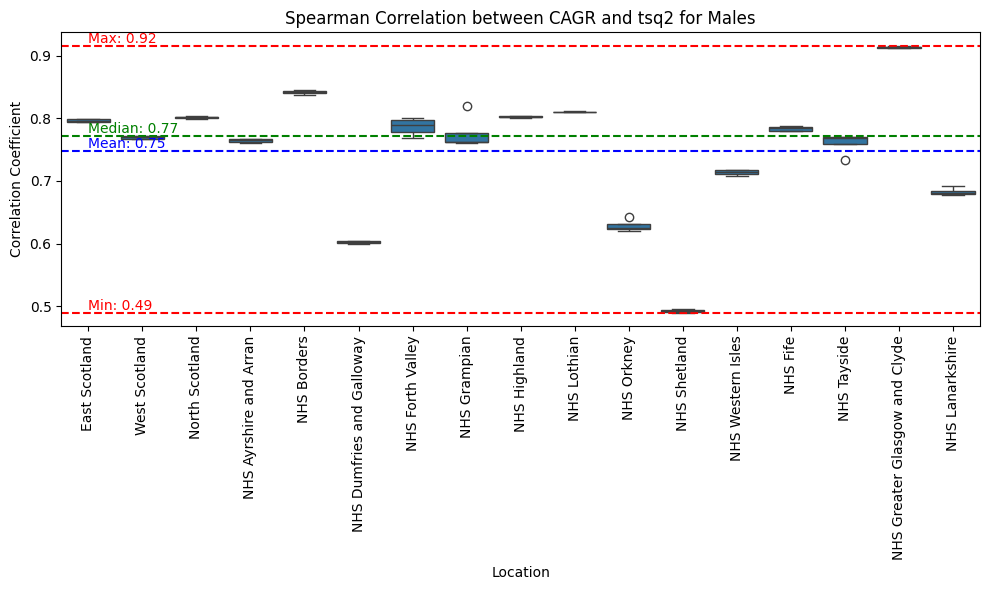

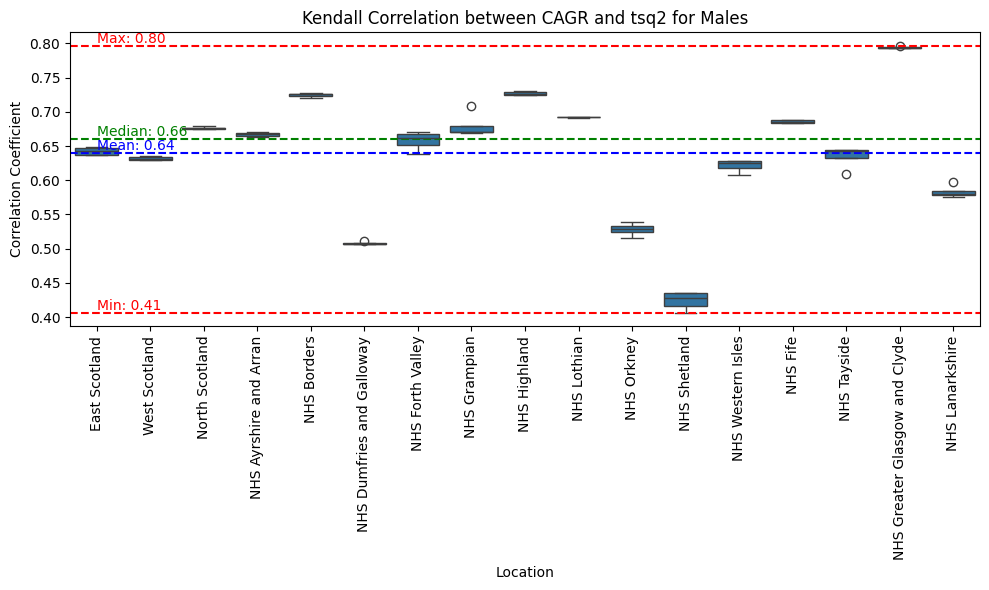

In [28]:
for corr_type in ["Pearson", "Spearman", "Kendall"]:
    data = [{"loc": loc, "corr": m_corr[loc][corr_type]} for loc in m_corr]
    plot_boxes(data, corr_type, gender="Males")

We see that there are a few cases where the correlation is below `0.6`, we isolate these cases and then check what's the issue.

In [34]:
from collections import defaultdict
f_low_mean = defaultdict(list)
for loc, corr in f_corr.items():
    for corr_type in corr:
        corr_mean = np.mean(corr[corr_type])
        if corr_mean <= 0.6:
            f_low_mean[corr_type].append(loc)
dict(f_low_mean)

{'Pearson': ['NHS Ayrshire and Arran',
  'NHS Borders',
  'NHS Highland',
  'NHS Shetland',
  'NHS Tayside'],
 'Spearman': ['NHS Grampian'],
 'Kendall': ['NHS Grampian', 'NHS Tayside']}

In [35]:
m_low_mean = defaultdict(list)
for loc, corr in m_corr.items():
    for corr_type in corr:
        corr_mean = np.mean(corr[corr_type])
        if corr_mean <= 0.6:
            m_low_mean[corr_type].append(loc)
dict(m_low_mean)

{'Kendall': ['NHS Dumfries and Galloway',
  'NHS Orkney',
  'NHS Shetland',
  'NHS Lanarkshire'],
 'Pearson': ['NHS Forth Valley',
  'NHS Grampian',
  'NHS Highland',
  'NHS Lothian',
  'NHS Orkney',
  'NHS Shetland',
  'NHS Lanarkshire'],
 'Spearman': ['NHS Shetland']}

In [67]:
loc_uniq = set()
for corr_type in f_low_mean:
    loc_uniq.update(f_low_mean[corr_type])
for corr_type in m_low_mean:
    loc_uniq.update(m_low_mean[corr_type])
len(loc_uniq), loc_uniq

(11,
 {'NHS Ayrshire and Arran',
  'NHS Borders',
  'NHS Dumfries and Galloway',
  'NHS Forth Valley',
  'NHS Grampian',
  'NHS Highland',
  'NHS Lanarkshire',
  'NHS Lothian',
  'NHS Orkney',
  'NHS Shetland',
  'NHS Tayside'})

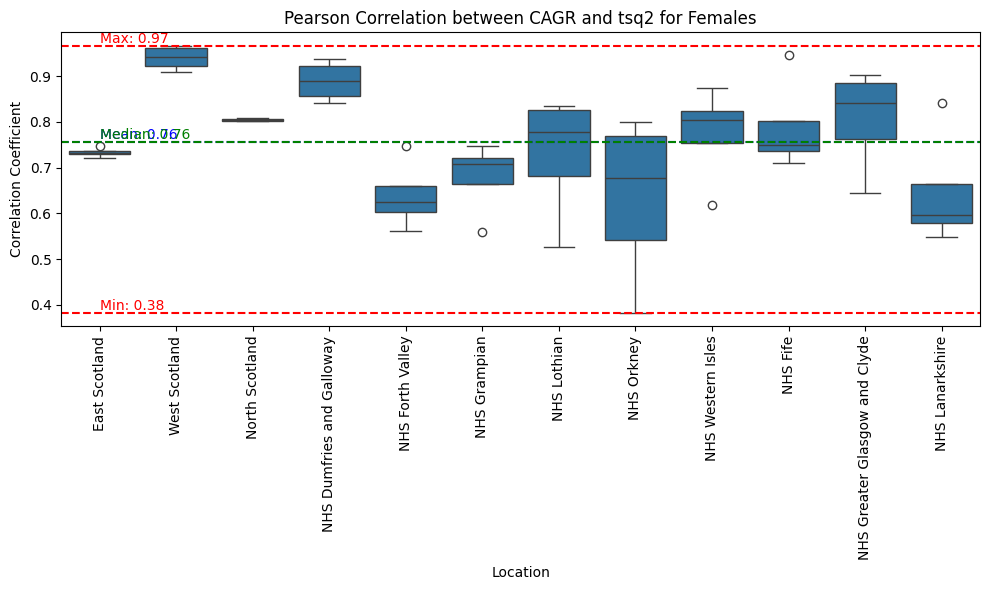

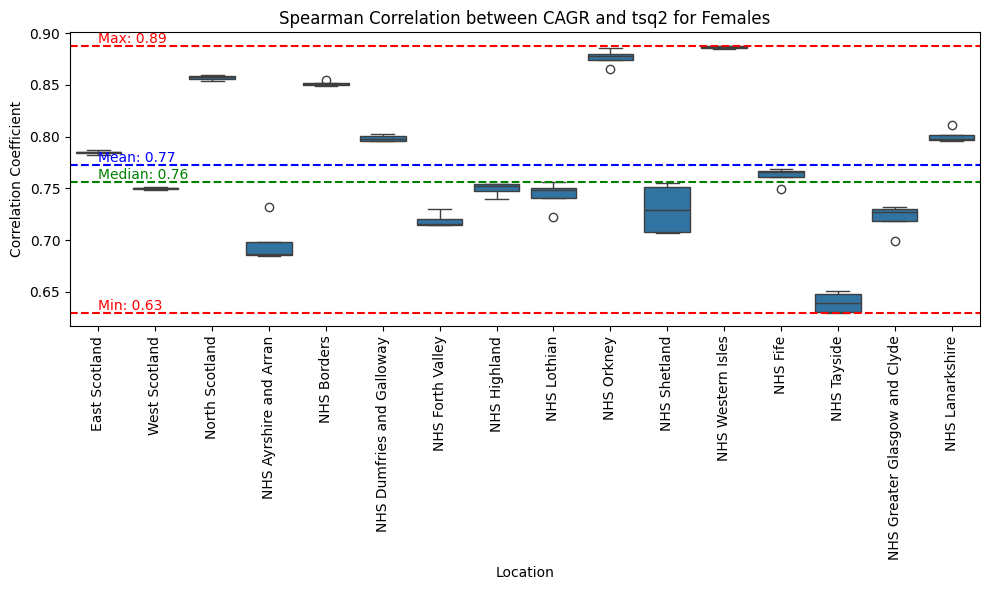

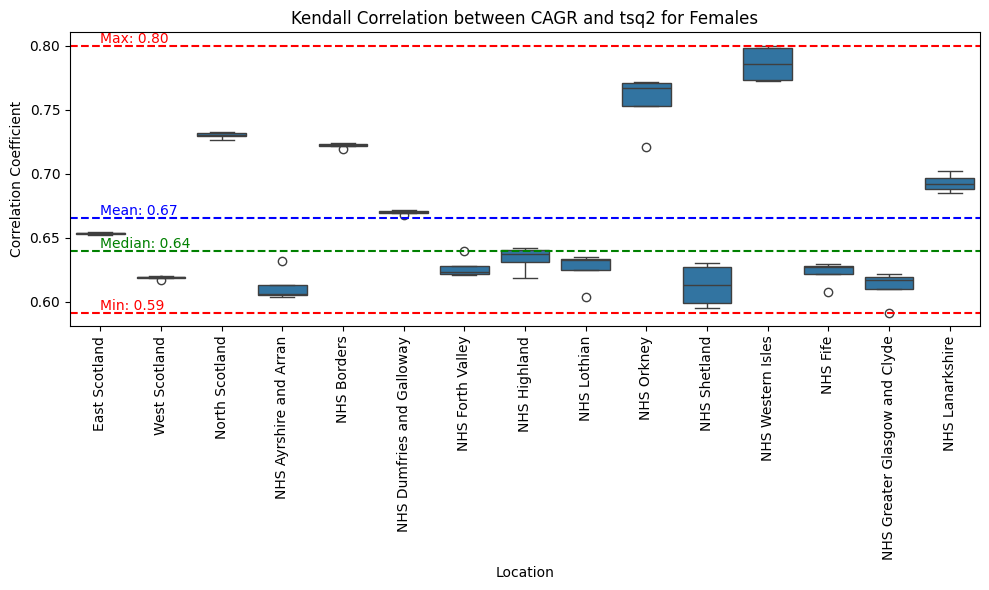

In [31]:
for corr_type in ["Pearson", "Spearman", "Kendall"]:
    f_data = [{"loc": loc, "corr": f_corr[loc][corr_type]} for loc in f_corr if loc not in f_low_mean.get(corr_type, [])]
    plot_boxes(f_data, corr_type)

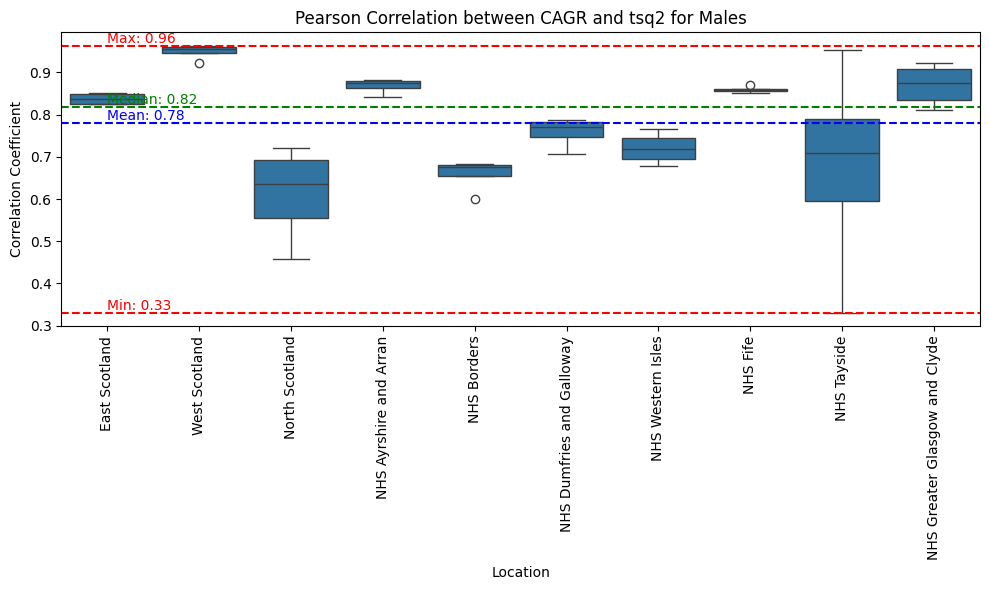

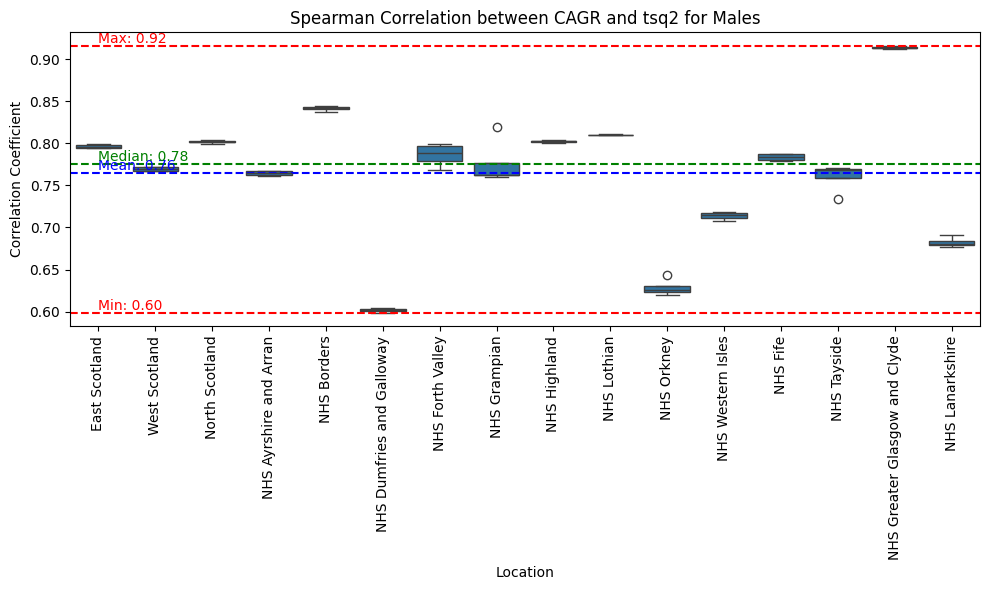

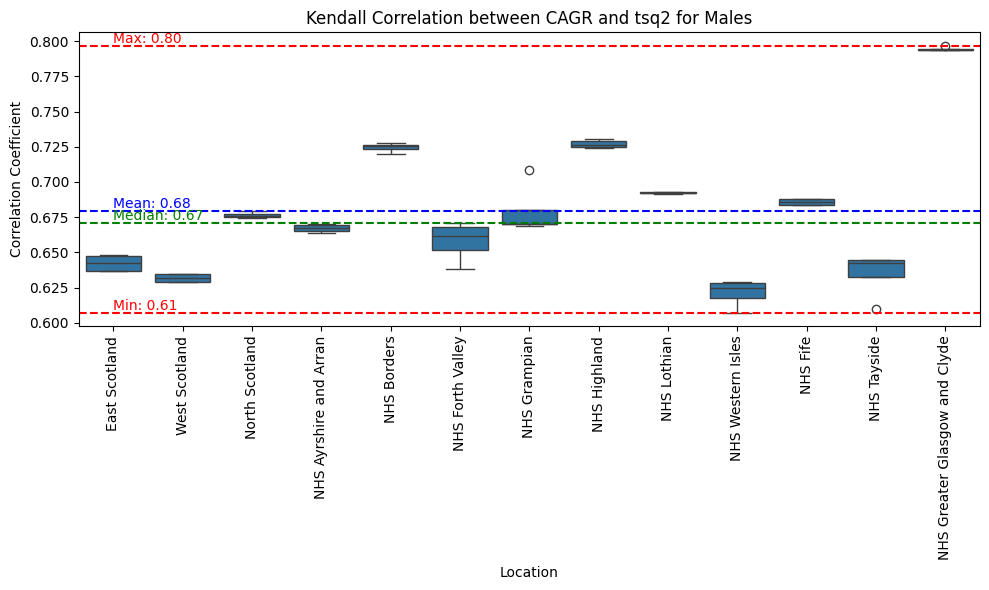

In [32]:
for corr_type in ["Pearson", "Spearman", "Kendall"]:
    m_data = [{"loc": loc, "corr": m_corr[loc][corr_type]} for loc in m_corr if loc not in m_low_mean.get(corr_type, [])]
    plot_boxes(m_data, corr_type, gender="Males")

In [65]:
from src.utils import *

def get_tsq_a(x, y=None, q=2, norm_mode="mean"):
    # Supports:
    # 1) get_tsq({year: value, ...}, q=2)
    # 2) get_tsq([years...], [values...], q=2)
    if y is None:
        if not isinstance(x, dict):
            raise ValueError("If 'y' is None, 'x' must be a dict of {x: y}.")
        x_arr = np.asarray(list(x.keys()), dtype=float)
        y_arr = np.asarray(list(x.values()), dtype=float)
    else:
        x_arr = np.asarray(x, dtype=float)
        y_arr = np.asarray(y, dtype=float)

    n = x_arr.size
    if n < 2:
        return 0.0

    # All pairwise slopes for i < j (vectorized)
    i, j = np.triu_indices(n, k=1)
    dx = x_arr[j] - x_arr[i]
    dy = y_arr[j] - y_arr[i]
    slopes = dy / dx  # dx != 0 for years
    ref_slopes = zip([int(x_arr[x]) for x in i], [int(x_arr[x]) for x in j], [float(s) for s in slopes])

    # Percentile selection
    percentile = 50 if q == 2 else 75 if q == 3 else 50
    order = np.argsort(slopes)
    slopes_sorted = slopes[order]
    i_sorted = i[order]
    j_sorted = j[order]

    m = slopes_sorted.size
    ts_index, weight_val = get_pos(m, percentile)
    frac = weight_val - ts_index

    if ts_index >= m - 1:
        ts_slope = slopes_sorted[-1]
        frac = 0.0
    else:
        ts_slope = slopes_sorted[ts_index] + frac * (slopes_sorted[ts_index + 1] - slopes_sorted[ts_index])

    # Normalization constant
    if norm_mode == "mean":
        norm_const = y_arr.mean()
    elif norm_mode == "median":
        norm_const = np.median(y_arr)
    elif norm_mode == "interval":
        if frac == 0.0 or ts_index >= m - 1:
            yrs_idx = np.array([i_sorted[ts_index], j_sorted[ts_index]])
        else:
            yrs_idx = np.unique(
                np.array([
                    i_sorted[ts_index], j_sorted[ts_index],
                    i_sorted[ts_index + 1], j_sorted[ts_index + 1]
                ])
            )
        norm_const = y_arr[yrs_idx].mean()
    elif norm_mode == "base":
        if frac == 0.0 or ts_index >= m - 1:
            yrs_idx = np.array([i_sorted[ts_index], j_sorted[ts_index]])
        else:
            yrs_idx = np.unique(
                np.array([
                    i_sorted[ts_index], j_sorted[ts_index],
                    i_sorted[ts_index + 1], j_sorted[ts_index + 1]
                ])
            )
        norm_const = y_arr[yrs_idx].min()
    else:
        raise ValueError("norm_mode must be one of: 'mean', 'median', 'interval'")
    
    print(norm_const)
    print(ts_slope)
    print(ts_index, m)
    print(list(ref_slopes))

    return round(100 * ts_slope / norm_const, 2) if norm_const != 0 else 0.0

In [66]:
a = [379, 416, 374, 356, 379, 387]

b = get_tsq_a(list(range(2014, 2020)), a)
b

381.8333333333333
0.0
7 15
[(2014, 2015, 37.0), (2014, 2016, -2.5), (2014, 2017, -7.666666666666667), (2014, 2018, 0.0), (2014, 2019, 1.6), (2015, 2016, -42.0), (2015, 2017, -30.0), (2015, 2018, -12.333333333333334), (2015, 2019, -7.25), (2016, 2017, -18.0), (2016, 2018, 2.5), (2016, 2019, 4.333333333333333), (2017, 2018, 23.0), (2017, 2019, 15.5), (2018, 2019, 8.0)]


np.float64(0.0)